# STEP 4 (v3) — Safety Validation, at BNF-Class Level, with Governance Compliance  
==================================================================================  
Adapted to Step 2 v3's output (bnf_class_otc_rules.parquet — NHS/OTC BNF  
classes, not individual SKUs) and to Mustafa's governance notes (Cell 39 of  
his data-access notebook):  
  
  "Rule level is research; patient level is not... Dissertation output must  
  be aggregate and anonymised... No patient-level records, and no small  
  cells that could re-identify someone. Set a minimum cell size, apply it,  
  and state it in the methods section."  
  
CHANGE FROM THE PREVIOUS VERSION — read this before assuming nothing moved:  
  - The old Part F saved an actionable_customer_list.csv with individual  
    CustomerKey values per rule. That is patient-level targeting output,  
    which the governance note appears to rule out for this project. It has  
    been REMOVED. Reach is now reported as an aggregate COUNT only.  
  - MIN_CELL_SIZE suppression has been added: any rule whose underlying  
    count falls below this threshold is dropped from published output  
    entirely (not just flagged) — small cells are how individuals get  
    re-identified even from "aggregate" tables.  
  - The old brand-substitution check (SKU text parsing) no longer applies  
    at BNF-class granularity — Step 2 already computes the class-level  
    equivalent (`is_same_class`), carried through here.  
  
Input:  
  - bnf_class_otc_rules.parquet (Step 2 v3)  
  - clean_transactions_all_drugs.parquet (Step 1)


No EDW authentication needed — runs entirely off Step 2 v3's saved parquet file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("step4_figures")
FIG_DIR.mkdir(exist_ok=True)

### CONFIG

In [3]:
LOOKBACK_DAYS = 30
RECENT_WINDOW_DAYS = 90
ALREADY_ESTABLISHED_THRESHOLD = 0.3
MIN_CELL_SIZE = 10   # governance: suppress any published count below this —
                       # state this value explicitly in your methods section

In [5]:
import os

def load_or_compute(checkpoint_name, compute_fn):
    """Reuses a saved result if it exists, otherwise computes and saves it."""
    path = f"checkpoint_{checkpoint_name}.parquet"
    if os.path.exists(path):
        print(f"[checkpoint] Loaded existing: {path}")
        return pd.read_parquet(path)
    result = compute_fn()
    result.to_parquet(path, index=False)
    print(f"[checkpoint] Saved: {path}")
    return result

### PART A — Load

In [6]:
rules = pd.read_parquet("bnf_class_otc_rules.parquet")
transactions = pd.read_parquet("clean_transactions_all_drugs.parquet")
transactions["dispense_date_created"] = pd.to_datetime(transactions["dispense_date_created"])
transactions["bnf_class"] = (
    transactions["ProductCodeLevel1"].astype(str) + transactions["ProductCodeLevel2"].astype(str)
)

print(f"[A] Loaded {len(rules):,} BNF-class rules and {len(transactions):,} transaction rows")

[A] Loaded 1,624 BNF-class rules and 67,124,000 transaction rows


### PART B — "Already taking it?" check, at BNF-class level

In [7]:
def already_established_check(nhs_class, otc_class, transactions_df, lookback_days=30):
    """
    For each occurrence of a customer buying a product in the NHS BNF
    class, checks whether they already had a product in the OTC BNF class
    in the lookback_days BEFORE that specific purchase occurrence.
    """
    ant_rows = transactions_df[transactions_df["bnf_class"] == nhs_class]
    anchors = ant_rows[["CustomerKey", "dispense_date_created"]].drop_duplicates()
    anchors = anchors.rename(columns={"dispense_date_created": "anchor_date"})

    if len(anchors) == 0:
        return pd.Series({
            "n_antecedent_occurrences": 0, "n_already_established": 0,
            "n_genuine_opportunity": 0, "pct_already_established": np.nan,
        })

    cons_rows = transactions_df[transactions_df["bnf_class"] == otc_class][
        ["CustomerKey", "dispense_date_created"]
    ].rename(columns={"dispense_date_created": "cons_date"})

    merged = anchors.merge(cons_rows, on="CustomerKey", how="left")
    merged["in_lookback"] = (
        merged["cons_date"].notna()
        & (merged["cons_date"] < merged["anchor_date"])
        & (merged["cons_date"] >= merged["anchor_date"] - pd.Timedelta(days=lookback_days))
    )

    established = merged.groupby(["CustomerKey", "anchor_date"])["in_lookback"].any()
    anchors_idx = anchors.set_index(["CustomerKey", "anchor_date"]).index
    established = established.reindex(anchors_idx, fill_value=False)

    n_total = len(established)
    n_already = int(established.sum())
    return pd.Series({
        "n_antecedent_occurrences": n_total,
        "n_already_established": n_already,
        "n_genuine_opportunity": n_total - n_already,
        "pct_already_established": n_already / n_total if n_total else np.nan,
    })

print(f"[B] Running 'already taking it?' check per rule "
      f"(lookback_days={LOOKBACK_DAYS}, {len(rules)} rules)")

#established_results = rules.apply(
#    lambda r: already_established_check(r["nhs_bnf_class"], r["otc_bnf_class"], transactions, LOOKBACK_DAYS),
#    axis=1,
#)
#rules = pd.concat([rules, established_results], axis=1)
#print(f"[B] Done. Mean 'already established' rate across rules: "
#      f"{rules['pct_already_established'].mean():.1%}")

def _compute_part_b():
    print(f"[B] Running 'already taking it?' check per rule "
          f"(lookback_days={LOOKBACK_DAYS}, {len(rules)} rules)")
    established_results = rules.apply(
        lambda r: already_established_check(r["nhs_bnf_class"], r["otc_bnf_class"], transactions, LOOKBACK_DAYS),
        axis=1,
    )
    return pd.concat([rules, established_results], axis=1)

rules = load_or_compute("step4_partB", _compute_part_b)
print(f"[B] Done. Mean 'already established' rate across rules: "
      f"{rules['pct_already_established'].mean():.1%}")

[B] Running 'already taking it?' check per rule (lookback_days=30, 1624 rules)
[checkpoint] Loaded existing: checkpoint_step4_partB.parquet
[B] Done. Mean 'already established' rate across rules: 4.0%


### PART C — Severe-interaction check

In [8]:
n_nonnull = transactions["severe_interaction_noted"].notna().sum()
print(f"\n[C] severe_interaction_noted field population: "
      f"{n_nonnull:,} / {len(transactions):,} rows non-null ({n_nonnull/len(transactions):.1%})")
print(transactions["severe_interaction_noted"].value_counts(dropna=False).to_string())

transactions["_interaction_flag"] = transactions["severe_interaction_noted"].astype(str).str.upper() == "Y"

def interaction_check(nhs_class, otc_class, transactions_df):
    combo_customers = set(
        transactions_df.loc[transactions_df["bnf_class"] == nhs_class, "CustomerKey"]
    ) & set(
        transactions_df.loc[transactions_df["bnf_class"] == otc_class, "CustomerKey"]
    )
    if len(combo_customers) == 0:
        return pd.Series({"n_combo_dispenses": 0, "n_flagged_interactions": 0, "interaction_rate": np.nan})
    relevant_rows = transactions_df[
        transactions_df["bnf_class"].isin({nhs_class, otc_class})
        & transactions_df["CustomerKey"].isin(combo_customers)
    ]
    n_flagged = relevant_rows["_interaction_flag"].sum()
    return pd.Series({
        "n_combo_dispenses": len(relevant_rows),
        "n_flagged_interactions": int(n_flagged),
        "interaction_rate": n_flagged / len(relevant_rows) if len(relevant_rows) else np.nan,
    })


#print("\n[C] Running empirical interaction check per rule")
#interaction_results = rules.apply(
#    lambda r: interaction_check(r["nhs_bnf_class"], r["otc_bnf_class"], transactions), axis=1,
#)
#rules = pd.concat([rules, interaction_results], axis=1)
#n_any_flagged = (rules["n_flagged_interactions"] > 0).sum()
#print(f"[C] {n_any_flagged} / {len(rules)} rules have at least one flagged interaction event")

def _compute_part_c():
    print("[C] Running empirical interaction check per rule")
    interaction_results = rules.apply(
        lambda r: interaction_check(r["nhs_bnf_class"], r["otc_bnf_class"], transactions), axis=1,
    )
    return pd.concat([rules, interaction_results], axis=1)

rules = load_or_compute("step4_partC", _compute_part_c)
n_any_flagged = (rules["n_flagged_interactions"] > 0).sum()
print(f"[C] {n_any_flagged} / {len(rules)} rules have at least one flagged interaction event")


[C] severe_interaction_noted field population: 67,124,000 / 67,124,000 rows non-null (100.0%)
N    67124000
[checkpoint] Loaded existing: checkpoint_step4_partC.parquet
[C] 0 / 1624 rules have at least one flagged interaction event


### PART D — Governance: minimum cell-size suppression

In [10]:
# Applied to n_ab (the count underlying support/confidence) AND to
# n_genuine_opportunity (the count underlying the "actionable" claim) —
# both are counts that could, at a small enough size, point at a
# re-identifiable handful of people.
n_before_suppression = len(rules)
rules_public = rules[
    (rules["n_ab"] >= MIN_CELL_SIZE) & (rules["n_genuine_opportunity"] >= MIN_CELL_SIZE)
].copy()
print(f"\n[D] Governance: minimum cell size = {MIN_CELL_SIZE}. "
      f"{n_before_suppression - len(rules_public)} rule(s) suppressed for having "
      f"a cell below this size; {len(rules_public)} remain for publication. "
      f"State MIN_CELL_SIZE explicitly in your methods section.")


[D] Governance: minimum cell size = 10. 0 rule(s) suppressed for having a cell below this size; 1624 remain for publication. State MIN_CELL_SIZE explicitly in your methods section.


### PART E — Final curated tables (aggregate only — no per-customer output)

In [14]:
clean_mask = (
    (rules_public["n_flagged_interactions"] == 0)
    & (rules_public["is_same_class"] == False)
)

best_per_otc_class = (
    rules_public[clean_mask]
    .sort_values("lift", ascending=False)   # was: n_genuine_opportunity
    .groupby("otc_class_name")
    .first()
    .reset_index()
    [["otc_class_name", "nhs_class_name", "support", "confidence", "lift",
      "pct_already_established", "n_genuine_opportunity"]]
)


print("\n=== Table: Best rule per distinct OTC class ===")
print(best_per_otc_class.to_string(index=False))
best_per_otc_class.to_csv("best_rule_per_otc_class.csv", index=False)

genuine_opportunity_rules = rules_public[
    clean_mask & (rules_public["pct_already_established"] <= ALREADY_ESTABLISHED_THRESHOLD)
].sort_values("n_genuine_opportunity", ascending=False)

print(f"\n=== Table: Rules with <= {ALREADY_ESTABLISHED_THRESHOLD:.0%} already-established "
      f"({len(genuine_opportunity_rules):,} / {len(rules_public):,} rules pass) ===")
print(
    genuine_opportunity_rules[
        ["nhs_class_name", "otc_class_name", "support", "confidence", "lift",
         "pct_already_established", "n_genuine_opportunity"]
    ].to_string(index=False)
)
genuine_opportunity_rules.to_csv("final_recommendations_genuine_opportunity.csv", index=False)


=== Table: Best rule per distinct OTC class ===
                                              otc_class_name                                             nhs_class_name  support  confidence       lift  pct_already_established  n_genuine_opportunity
                                                        0111       Antispasmodics and other drugs altering gut motility 0.000013    0.013016  16.749112                 0.037336                74284.0
                                                        1102                            Anti-infective eye preparations 0.000002    0.001231  46.639398                 0.009870                67915.0
                                                       A1037                                    Topical corticosteroids 0.000028    0.004764  13.339072                 0.165080               243855.0
                                                       A1038                            Anti-infective eye preparations 0.000008    0.005549   6.843100

In [15]:
print(rules_public.loc[
    (rules_public["nhs_class_name"] == "Minerals") & (rules_public["otc_class_name"].str.contains("ACBS")),
    ["n_ab", "n_nhs_class", "n_otc_class", "support", "confidence", "lift"]
])

     n_ab  n_nhs_class  n_otc_class   support  confidence        lift
566   539        16512         5345  0.000011    0.032643  299.302534


### PART F — Reach, AGGREGATE COUNT ONLY (governance fix: no CustomerKey list)

In [16]:
as_of_date = transactions["dispense_date_created"].max()

def compute_reach_count(nhs_class, otc_class, transactions_df, recent_window_days, as_of_date):
    """
    Aggregate reach count only. Deliberately does NOT return the underlying
    CustomerKey set — per governance, this project's output must be
    aggregate/anonymised, and a per-customer targeting list is a different
    activity with a different lawful basis, out of scope here.
    """
    cutoff = as_of_date - pd.Timedelta(days=recent_window_days)
    recent_ant = transactions_df[
        (transactions_df["bnf_class"] == nhs_class)
        & (transactions_df["dispense_date_created"] >= cutoff)
    ]
    candidates = set(recent_ant["CustomerKey"].unique())
    already_have = set(
        transactions_df.loc[transactions_df["bnf_class"] == otc_class, "CustomerKey"]
    )
    return len(candidates - already_have)

print(f"\n[F] Computing aggregate reach for top rules by lift "
      f"(recent_window_days={RECENT_WINDOW_DAYS}) — count only, no customer-level output")

top_by_lift = rules_public[clean_mask].sort_values("lift", ascending=False).head(20).copy()
top_by_lift["reach"] = top_by_lift.apply(
    lambda r: compute_reach_count(r["nhs_bnf_class"], r["otc_bnf_class"], transactions, RECENT_WINDOW_DAYS, as_of_date),
    axis=1,
)

# Governance: suppress reach itself if below the cell-size floor too
top_by_lift.loc[top_by_lift["reach"] < MIN_CELL_SIZE, "reach"] = np.nan
n_reach_suppressed = top_by_lift["reach"].isna().sum()
print(f"[F] {n_reach_suppressed} rule(s) had reach below MIN_CELL_SIZE — suppressed, not published as a number")

reach_summary = top_by_lift[
    ["nhs_class_name", "otc_class_name", "lift", "reach"]
].sort_values(["lift"], ascending=False)
print("\n=== Table: Lift + aggregate reach for top rules (prioritisation view) ===")
print(reach_summary.to_string(index=False))
reach_summary.to_csv("rules_lift_and_reach.csv", index=False)


[F] Computing aggregate reach for top rules by lift (recent_window_days=90) — count only, no customer-level output
[F] 0 rule(s) had reach below MIN_CELL_SIZE — suppressed, not published as a number

=== Table: Lift + aggregate reach for top rules (prioritisation view) ===
                                      nhs_class_name                                         otc_class_name       lift   reach
                                            Minerals ACBS — Nutritional supplements / borderline substances 299.302534 40954.0
                                            Minerals                         Drugs acting on the oropharynx  73.435293 42863.0
                                    Antifungal drugs             Treatment of vaginal and vulval conditions  55.537934  4199.0
               Preparations for eczema and psoriasis                       Anti-infective skin preparations  53.199782  5301.0
                                            Vitamins ACBS — Nutritional supplements / bord

### PART G — Group rules by NHS BNF chapter (coarser than class) for the plot


=== Table: Surviving rules by NHS BNF chapter ===
02    289
04    275
06    178
01    153
03    148
13    122
10     73
07     73
09     68
05     65
11     51
08     49
12     44
A1      8


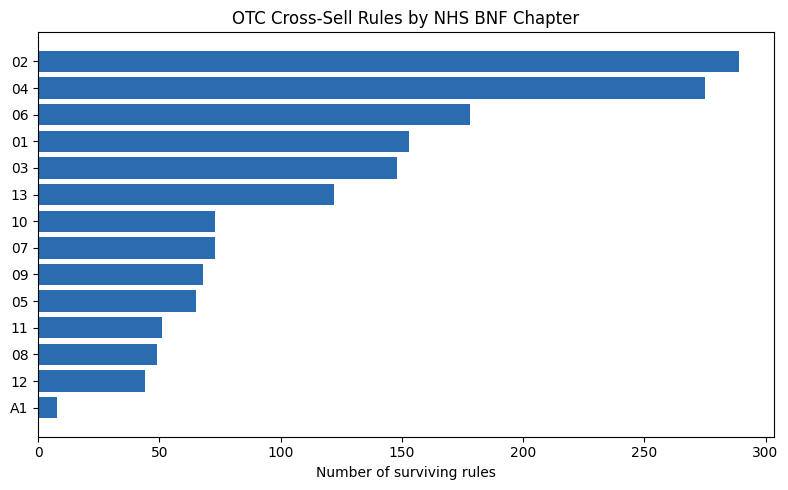


All Step 4 outputs saved (aggregate only, MIN_CELL_SIZE=10 enforced). Figures in /mnt/batch/tasks/shared/LS_root/mounts/clusters/smrttempcins01/code/Users/FKSU/step4_figures


In [17]:
rules_public["nhs_chapter"] = rules_public["nhs_bnf_class"].str[:2]

chapter_counts = (
    rules_public[clean_mask]["nhs_chapter"]
    .value_counts()
    .sort_values(ascending=False)
)
print("\n=== Table: Surviving rules by NHS BNF chapter ===")
print(chapter_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(chapter_counts.index.astype(str)[::-1], chapter_counts.values[::-1], color="#2b6cb0")
ax.set_xlabel("Number of surviving rules")
ax.set_title("OTC Cross-Sell Rules by NHS BNF Chapter")
plt.tight_layout()
plt.savefig(FIG_DIR / "rules_by_bnf_chapter.png", dpi=300)
plt.show()

print(f"\nAll Step 4 outputs saved (aggregate only, MIN_CELL_SIZE={MIN_CELL_SIZE} enforced). "
      f"Figures in {FIG_DIR.resolve()}")